# Continuous-spacial GCMC

c:\Users\y_7up\Documents\projects\mi_dev\.env3.9\Lib\site-packages\pymatgen\core\structure.py:3109: UserWarning: Issues encountered while parsing CIF: Skipping relative stoichiometry check because CIF does not contain formula keys.
  struct = parser.parse_structures(primitive=primitive)[0]


beta: 2.4305270188053424e+20
beta * U_percentile[50, 90, 99, 99.9]: [   3.94093231 1682.18530388 2684.1608269  3019.18528361]
Henry constant: 1e-05


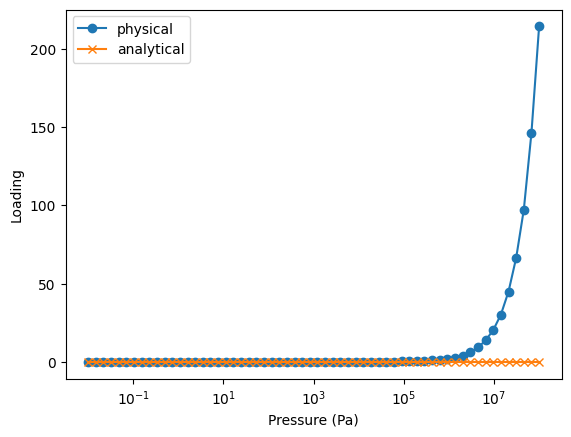

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.constants import h, k, Avogadro, R
from c02_raspa_data_parsers import RaspaForceField
from c02_cif_data_loader import CifToStructure, SimulationStructure
from c01_energy_calculators import EnergyMatrixCalculator
from c01_isotherm_simulation import IsothermSimulator
from c01_compute_henry_constant import compute_henry_constant


# ==========================================================
# random seed
# ==========================================================
np.random.seed(0)

# ==========================================================
# constants
# ==========================================================
angstrom = 1e-10

# ==========================================================
# environment
# ==========================================================
pressures = np.logspace(-2, 8, 60)
# pressures = np.logspace(5, 8, 40) # この設定値は本来不適切
temperature = 298.0

# ==========================================================
# force field
# ==========================================================
json_path = Path(r"C:\Users\y_7up\Documents\projects\mi_dev\03_mof\input\02_GCMC_input\11_mc_adsorption_of_co2_in_cu_btc\force_field.json")


ff = RaspaForceField(json_path)

# ==========================================================
# structure
# ==========================================================
cif_path = Path(r"C:\Users\y_7up\Documents\projects\mi_dev\03_mof\input\02_GCMC_input\11_mc_adsorption_of_co2_in_cu_btc\Cu-BTC.cif")

cts = CifToStructure()

pymatgen_struct = cts.cif_to_structure(cif_path)

sim_struct = SimulationStructure(
    pymatgen_struct,
    force_field=ff
)

box = sim_struct.box

# ==========================================================
# grid
# ==========================================================
res = 1.0 * angstrom # unit conversion

x = np.arange(0, box[0], res)
y = np.arange(0, box[1], res)
z = np.arange(0, box[2], res)

grid = {
    "x": x,
    "y": y,
    "z": z
}

# ==========================================================
# boundary
# ==========================================================

cutoff = 12.0 * angstrom

# ==========================================================
# energy calculator
# ==========================================================

energy_calc = EnergyMatrixCalculator(
    structure=sim_struct,
    force_field=ff,
    grid=grid,
    cutoff=ff.get_cutoff() * 1e-10
)

energy_calc.build_energy_grid() # return energy_grid

energies, dV = energy_calc.get_energy_distribution() # energies: energy_grid (array of U)

# for debug
beta = 1.0 / (k * temperature)
print(f'beta: {beta}')
print("beta * U_percentile[50, 90, 99, 99.9]:", beta * np.percentile(energies, [50, 90, 99, 99.9])) # print(np.percentile(U, [50, 90, 99, 99.9]))

# ==========================================================
# GCMC simulation
# ==========================================================
mu0_value = 0.0 # None # 0.0 ← autoの時は不要になる：内部で上書き

mc_isotherm, analytic_iso, valid_data, mu, N_history = \
    IsothermSimulator.run_isotherm(
        energy_calc=energy_calc,
        box=box,
        energies=energies,
        dV=dV,
        T=temperature,
        pressures=pressures,
        m_molar=0.016, # kg/mol ⇒ 内部でkg/particleに変換するため、ここでは分子量を与える
        mu0_value=mu0_value,
        mu0_mode="auto", # "auto", "constant", or "zero" : adsorption_model="continuous" かつ mu0_mode = constantだと警告が出る仕組み
        adsorption_model="continuous" # デフォルトが"continuous" だが、ここは明示的に(格子モデルならlattice)
        n_steps = int(2e5) # デフォルト値そのまま
    )


# ==========================================================
# Henry constant
# ==========================================================

KH = compute_henry_constant(valid_data["energies"], T=temperature, P0=1e5)

print("Henry constant:", KH)

# ==========================================================
# plot
# ==========================================================

plt.figure()

plt.semilogx(pressures, mc_isotherm, marker='o', label="physical")
plt.semilogx(pressures, analytic_iso, marker='x', label="analytical")

plt.xlabel("Pressure (Pa)")
plt.ylabel("Loading")

plt.legend()
plt.show()


# 以下は出力検証用